# Preprocess Raw Data

Thin notebook driver. Logic lives in `src/dataset/clean/`, `dedupe/`, `preprocess/`.

See `docs/Patterns.md` — **Notebook Driver + src Utility**.

Pipeline for `data/raw/documents.jsonl`:

1. **Inspect** — what format is the data? what training strategy does it imply?
2. **Clean** — strip HTML, control chars, broken unicode, short texts
3. **Dedupe** — remove exact duplicates
4. **Length analysis** — decide `max_seq_length`

**Outputs:**
- `data/cleaned/documents.jsonl`
- `data/deduped/documents.jsonl`
- `data/processed/stats.json`

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from dataset.clean.text_cleaner import clean_text, is_valid_text
from dataset.dedupe.exact_dedupe import dedupe_records
from dataset.paths import data_dir, resolve_repo_root
from dataset.preprocess.inspect import inspect_dataset, load_jsonl, save_jsonl
from dataset.preprocess.length_analysis import analyze_lengths, recommend_max_seq_length
from dataset.preprocess.pipeline import PreprocessConfig, run_preprocess

REPO_ROOT = resolve_repo_root(REPO_ROOT)
DATA = data_dir(REPO_ROOT)

RAW_PATH = DATA / "raw" / "documents.jsonl"
CLEANED_PATH = DATA / "cleaned" / "documents.jsonl"
DEDUPED_PATH = DATA / "deduped" / "documents.jsonl"
STATS_PATH = DATA / "processed" / "stats.json"

MIN_CHARS = 50
MIN_WORDS = 10

print(f"Input:  {RAW_PATH}")
print(f"Exists: {RAW_PATH.exists()}")

Input:  /home/yash/Desktop/repo/data/raw/documents.jsonl
Exists: True


## Phase 1: Dataset Inspection

Before touching tokenizers, answer: **what exactly is your data?**

In [2]:
raw_records = load_jsonl(RAW_PATH)
inspection = inspect_dataset(raw_records)

print(json.dumps(inspection, indent=2, ensure_ascii=False))

print("\n--- Training implication ---")
print(inspection["training_strategy"])

{
  "count": 56436,
  "format": "single_text",
  "fields": [
    "char_count",
    "crawl_id",
    "id",
    "text",
    "url",
    "warc_record_id",
    "wet_file"
  ],
  "field_coverage": {
    "id": 1.0,
    "warc_record_id": 1.0,
    "url": 1.0,
    "crawl_id": 1.0,
    "wet_file": 1.0,
    "text": 1.0,
    "char_count": 1.0
  },
  "sample_keys": [
    "id",
    "warc_record_id",
    "url",
    "crawl_id",
    "wet_file",
    "text",
    "char_count"
  ],
  "sample_preview": {
    "id": "57a1b35c647712df2068eaf25c4ed6e602166a86",
    "warc_record_id": "<urn:uuid:c6b329d7-dea9-4411-ba16-4947fa62fa86>",
    "url": "http://0.galgameo.com/636.html",
    "crawl_id": "CC-MAIN-2024-46",
    "wet_file": "crawl-data/CC-MAIN-2024-46/segments/1730477028545.2/wet/CC-MAIN-20241114062951-20241114092951-00110.warc.wet.gz",
    "text": "【ACT/中文/全动态】女骑士与食人魔洞窟： DL官方中文版 【600M】【新作/全CV】-0商品\n0商品\nACG游戏\nRPG游戏\nSLG游戏\n3D游戏\nADV游戏\nACT游戏\nFPS游戏\nHTML游戏\n真人游戏\n动漫动画\n动漫动画\n短视频",
    "char_count": "4177"
  

## Phase 2: Cleaning

Raw internet text is noisy. Remove HTML, control characters, broken unicode, duplicate whitespace, and very short documents.

In [3]:
cleaned_records = []
rejected_short = 0

for record in raw_records:
    text = clean_text(record.get("text", ""))
    if not is_valid_text(text, min_chars=MIN_CHARS, min_words=MIN_WORDS):
        rejected_short += 1
        continue

    cleaned = {**record, "text": text, "char_count": len(text)}
    cleaned_records.append(cleaned)

save_jsonl(cleaned_records, CLEANED_PATH)

clean_stats = {
    "input_count": len(raw_records),
    "output_count": len(cleaned_records),
    "rejected_short": rejected_short,
    "rejection_ratio": rejected_short / len(raw_records) if raw_records else 0.0,
}

print(json.dumps(clean_stats, indent=2))
print(f"\nSaved -> {CLEANED_PATH}")

if cleaned_records:
    before = raw_records[0]["text"][:300]
    after = cleaned_records[0]["text"][:300]
    print("\nBefore:", repr(before))
    print("After: ", repr(after))

{
  "input_count": 56436,
  "output_count": 56432,
  "rejected_short": 4,
  "rejection_ratio": 7.0876745339854e-05
}

Saved -> /home/yash/Desktop/repo/data/cleaned/documents.jsonl

Before: '【ACT/中文/全动态】女骑士与食人魔洞窟： DL官方中文版 【600M】【新作/全CV】-0商品\n0商品\nACG游戏\nRPG游戏\nSLG游戏\n3D游戏\nADV游戏\nACT游戏\nFPS游戏\nHTML游戏\n真人游戏\n动漫动画\n动漫动画\n短视频\n未分类\n限时免费\n安卓单机\n嗨手游\n游戏教程\n游戏教程\n游戏MOD工具\n客服论坛\n最新发布\n秘密入口\n交换资源论坛\n登录注册\n搜索\n当前位置：首页 ACG游戏 ACT游戏 正文\n下载说明：没有下载链接的，就搜索新版，没新版的去发邮件xacgvip@gmail.com求链接！\n【ACT/中文/全动态】女骑士与食人魔洞窟： DL官方中文版 【600M】【新作/'
After:  '【ACT/中文/全动态】女骑士与食人魔洞窟: DL官方中文版 【600M】【新作/全CV】-0商品 0商品 ACG游戏 RPG游戏 SLG游戏 3D游戏 ADV游戏 ACT游戏 FPS游戏 HTML游戏 真人游戏 动漫动画 动漫动画 短视频 未分类 限时免费 安卓单机 嗨手游 游戏教程 游戏教程 游戏MOD工具 客服论坛 最新发布 秘密入口 交换资源论坛 登录注册 搜索 当前位置:首页 ACG游戏 ACT游戏 正文 下载说明:没有下载链接的,就搜索新版,没新版的去发邮件xacgvip@gmail.com求链接! 【ACT/中文/全动态】女骑士与食人魔洞窟: DL官方中文版 【600M】【新作/'


## Phase 3: Deduplication

Embedding models memorize exact duplicates instead of learning useful representations.

In [4]:
deduped_records, dedupe_stats = dedupe_records(cleaned_records)
save_jsonl(deduped_records, DEDUPED_PATH)

print(json.dumps(dedupe_stats, indent=2))
print(f"\nSaved -> {DEDUPED_PATH}")

{
  "input_count": 56432,
  "output_count": 56224,
  "duplicates_removed": 208,
  "dedupe_ratio": 0.003685851998865892
}

Saved -> /home/yash/Desktop/repo/data/deduped/documents.jsonl


## Phase 4: Length Analysis

Use word-count distribution to pick `max_seq_length`. If 95% of docs are under 128 words, don't waste memory on 512.

Length stats (words):
  count: 56224
  min_words: 11
  mean_words: 952.7
  p50_words: 549
  p95_words: 2924
  p99_words: 6688
  max_words: 71119

Recommended max_seq_length: 3072
Reason: p95 = 2924 words -> round up to 3072


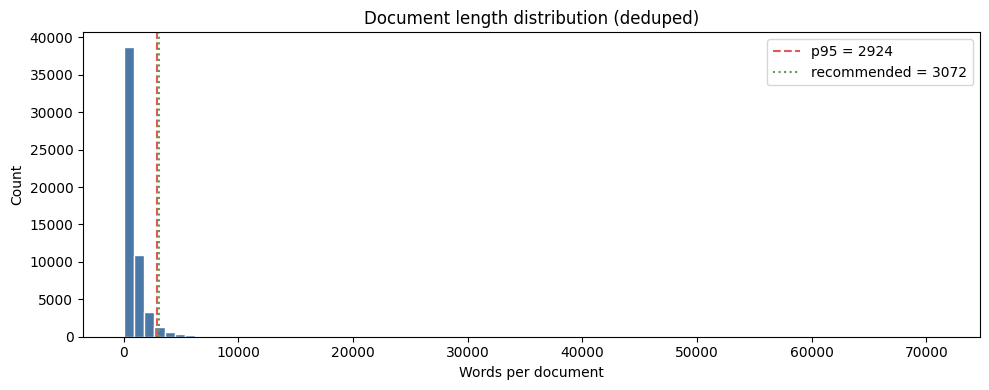

In [5]:
length_stats = analyze_lengths(records=deduped_records)
recommended = recommend_max_seq_length(int(length_stats["p95_words"]))

print("Length stats (words):")
for key, value in length_stats.items():
    print(f"  {key}: {value}")

print(f"\nRecommended max_seq_length: {recommended}")
print(f"Reason: p95 = {length_stats['p95_words']} words -> round up to {recommended}")

lengths = [len(r["text"].split()) for r in deduped_records]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lengths, bins=80, color="#4C78A8", edgecolor="white")
ax.axvline(length_stats["p95_words"], color="#E45756", linestyle="--", label=f"p95 = {length_stats['p95_words']}")
ax.axvline(recommended, color="#54A24B", linestyle=":", label=f"recommended = {recommended}")
ax.set_xlabel("Words per document")
ax.set_ylabel("Count")
ax.set_title("Document length distribution (deduped)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
stats = {
    "inspection": inspection,
    "cleaning": clean_stats,
    "deduplication": dedupe_stats,
    "length_analysis": length_stats,
    "recommended_max_seq_length": recommended,
    "paths": {
        "raw": str(RAW_PATH.relative_to(REPO_ROOT)),
        "cleaned": str(CLEANED_PATH.relative_to(REPO_ROOT)),
        "deduped": str(DEDUPED_PATH.relative_to(REPO_ROOT)),
    },
}

with open(STATS_PATH, "w", encoding="utf-8") as fh:
    json.dump(stats, fh, indent=2)

print(f"Stats saved -> {STATS_PATH}")
print(json.dumps(stats, indent=2))

Stats saved -> /home/yash/Desktop/repo/data/processed/stats.json
{
  "inspection": {
    "count": 56436,
    "format": "single_text",
    "fields": [
      "char_count",
      "crawl_id",
      "id",
      "text",
      "url",
      "warc_record_id",
      "wet_file"
    ],
    "field_coverage": {
      "id": 1.0,
      "warc_record_id": 1.0,
      "url": 1.0,
      "crawl_id": 1.0,
      "wet_file": 1.0,
      "text": 1.0,
      "char_count": 1.0
    },
    "sample_keys": [
      "id",
      "warc_record_id",
      "url",
      "crawl_id",
      "wet_file",
      "text",
      "char_count"
    ],
    "sample_preview": {
      "id": "57a1b35c647712df2068eaf25c4ed6e602166a86",
      "warc_record_id": "<urn:uuid:c6b329d7-dea9-4411-ba16-4947fa62fa86>",
      "url": "http://0.galgameo.com/636.html",
      "crawl_id": "CC-MAIN-2024-46",
      "wet_file": "crawl-data/CC-MAIN-2024-46/segments/1730477028545.2/wet/CC-MAIN-20241114062951-20241114092951-00110.warc.wet.gz",
      "text": "\u3010AC